<h1><b>Modelo de Previsão para Séries Temporais</b><br>
<i>Previsão de demanda</i></h1>

## Componentes das Séries Temporais
Uma série temporal pode ser decomposta em:

- Tendência: direção de longo prazo
- Sazonalidade: repetição periódica de padrões
- Ruído: variação aleatória
<br>

<b>Importação das bibliotecas<br>
Estilizações para os Gráficos e<br>
Leitura dos dados</b>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import seaborn as sns
from itertools import product
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss


plot_config= {
        "axes.facecolor": "#fff",     # Cor de fundo dos gráficos
        "axes.spines.top": False,     # Ativar ou remover borda superior
        "axes.spines.right": False,   # Ativar ou remover borda direita
        "axes.grid": False,           # Ativar ou remover grade
        "figure.figsize": (15, 6)     # Tamanho padrão da figura
}

plt.rcParams.update(plot_config)
sns.set_theme(rc= plot_config)


df = pd.read_csv("../../data/raw/demand.csv",
    usecols=['date', 'sales'],
    index_col="date",
    parse_dates=["date"]
)
df = df.resample('ME').sum(numeric_only=True)
df.head(2)

,sales
date,
2013-01-31,454904
2013-02-28,459417


<h3>Visualização da Série Temporal</h3>

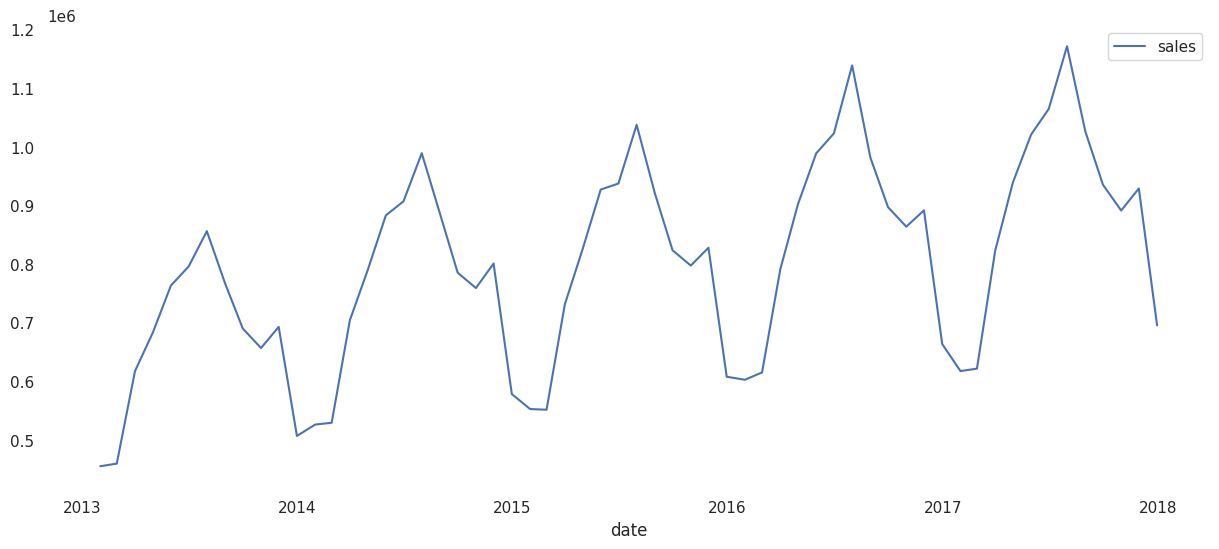

In [2]:
sns.lineplot(df);

### Estacionalidade

In [3]:
def test_stationarity(series, label='Série'):
    """Aplica ADF e KPSS e exibe resultado formatado."""
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series.dropna(), autolag='AIC')
    kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')

    estac_adf  = 'Estacionária ✓' if adf_p < 0.05 else 'Não estacionária ✗'
    estac_kpss = 'Estacionária ✓' if kpss_p > 0.05 else 'Não estacionária ✗'

    print(f"\n{'='*55}")
    print(f" {label}")
    print(f"{'='*55}")
    print(f" ADF  → estatística: {adf_stat:8.4f}  p-valor: {adf_p:.4f}  → {estac_adf}")
    print(f" KPSS → estatística: {kpss_stat:8.4f}  p-valor: {kpss_p:.4f}  → {estac_kpss}")
    return adf_p < 0.05

# Nível original
is_stationary = test_stationarity(df['sales'], 'Série Original (nível)')

# 1ª diferença
df['sales_diff1'] = df['sales'].diff()
test_stationarity(df['sales_diff1'].dropna(), '1ª Diferença')

# 1ª diferença sazonal (lag=12)
df['sales_diff1_12'] = df['sales'].diff().diff(12)
test_stationarity(df['sales_diff1_12'].dropna(), '1ª Diferença + Diferença Sazonal (lag=12)')


 Série Original (nível)
 ADF  → estatística:  -5.2475  p-valor: 0.0000  → Estacionária ✓
 KPSS → estatística:   0.5360  p-valor: 0.0335  → Não estacionária ✗

 1ª Diferença
 ADF  → estatística:  -1.5290  p-valor: 0.5191  → Não estacionária ✗
 KPSS → estatística:   0.0777  p-valor: 0.1000  → Estacionária ✓

 1ª Diferença + Diferença Sazonal (lag=12)
 ADF  → estatística:  -6.5854  p-valor: 0.0000  → Estacionária ✓
 KPSS → estatística:   0.0605  p-valor: 0.1000  → Estacionária ✓


/tmp/ipykernel_18706/186436608.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')
/tmp/ipykernel_18706/186436608.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')


np.True_

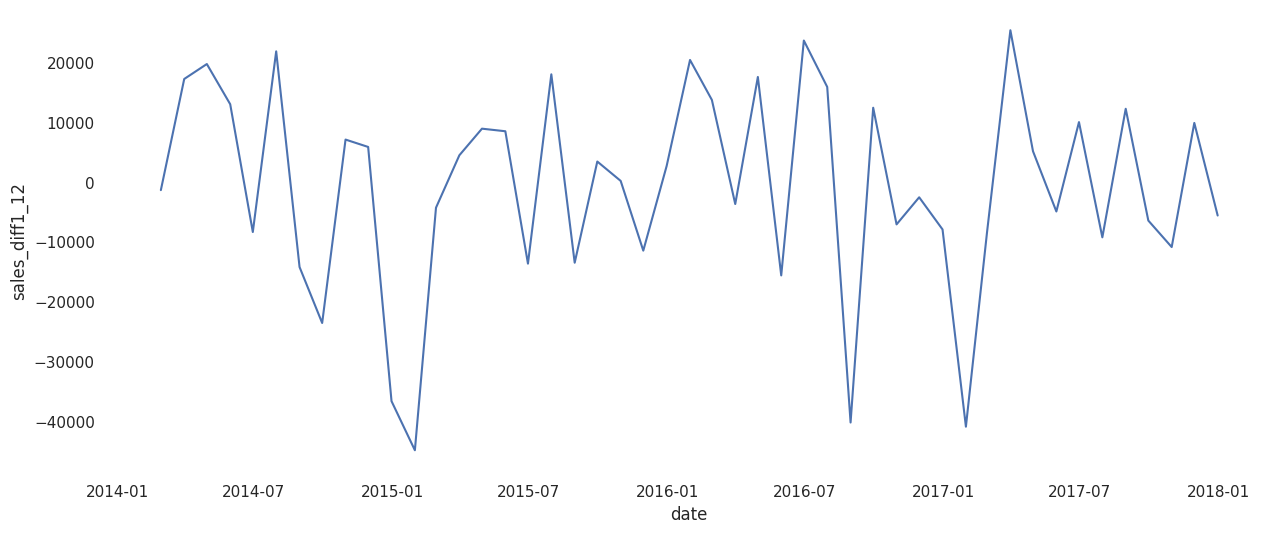

In [4]:
sns.lineplot(df['sales_diff1_12']);

### ACF e PACF para identificação de parâmetros

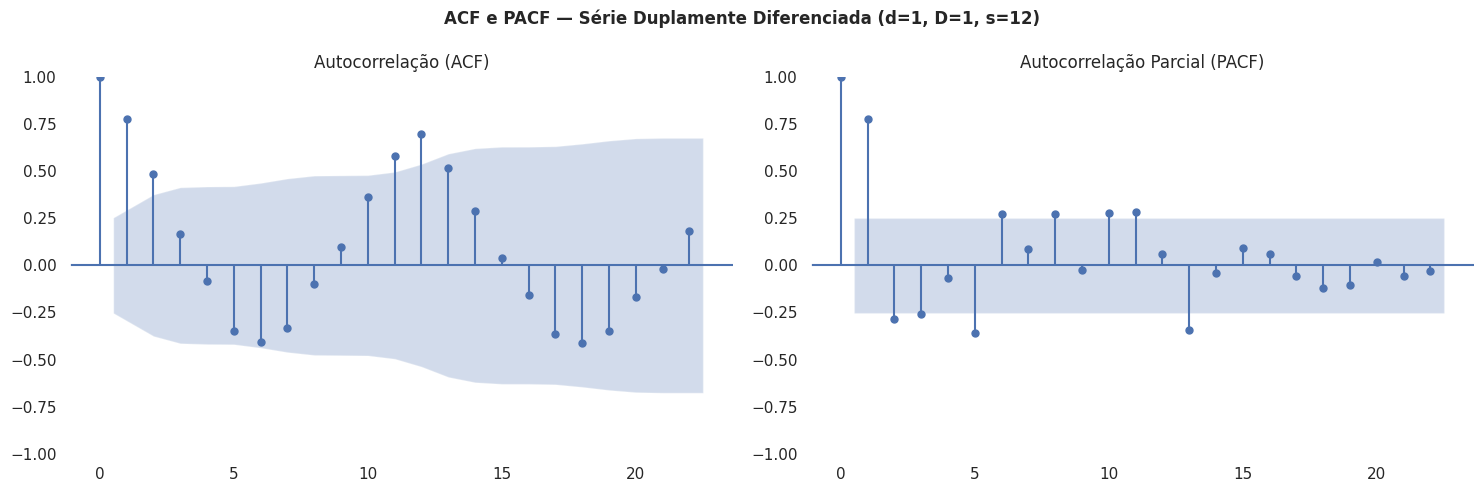

In [5]:
series_for_acf = df['sales']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ACF e PACF — Série Duplamente Diferenciada (d=1, D=1, s=12)', fontsize=12, fontweight='bold')

plot_acf(series_for_acf,  ax=axes[0], lags=22, title='Autocorrelação (ACF)')
plot_pacf(series_for_acf, ax=axes[1], lags=22, method='ywm', title='Autocorrelação Parcial (PACF)')

plt.tight_layout()
plt.show()

## Grid Search de Hiperparâmetros SARIMA

In [6]:
# Espaço de busca — ajuste conforme necessidade e tempo disponível
# SARIMA(p,d,q)(P,D,Q)[s]
p_values = [0, 1, 2]
d_values = [1]          # d=1 indicado pelos testes
q_values = [0, 1, 2]
P_values = [0, 1, 2]
D_values = [1]          # D=1 para sazonalidade
Q_values = [0, 1, 2]
s = 12                  # sazonalidade anual

train = df['sales']

results = []

# parâmetros fixos
d = 1
D = 1
s = 12

total = len(p_values) * len(q_values) * len(P_values) * len(Q_values)
count = 0

for p in p_values:
    for q in q_values:
        for P in P_values:
            for Q in Q_values:

                count += 1

                # evitar modelo trivial
                if p == 0 and q == 0 and P == 0 and Q == 0:
                    continue

                # filtro de complexidade
                if (p + q + P + Q) > 4:
                    continue

                try:
                    model = SARIMAX(
                        train,
                        order=(p, d, q),
                        seasonal_order=(P, D, Q, s),
                        enforce_stationarity=True,
                        enforce_invertibility=True
                    )

                    fit = model.fit(disp=False)

                    results.append({
                        'order': (p, d, q),
                        'seasonal_order': (P, D, Q, s),
                        'AIC': round(fit.aic, 2),
                        'BIC': round(fit.bic, 2)
                    })

                except Exception as e:
                    print(f'Erro em {(p,d,q)} {(P,D,Q,s)}: {e}')
                    break

                if count % 10 == 0:
                    print(f'{count}/{total} combinações testadas...')

results_df = (
    pd.DataFrame(results)
    .sort_values('AIC')
    .reset_index(drop=True)
)

print('\nTop 10 modelos por AIC:\n')
print(results_df.head(10))

/home/red/Projects/forecast_demand/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


10/81 combinações testadas...
20/81 combinações testadas...
30/81 combinações testadas...
40/81 combinações testadas...

Top 10 modelos por AIC:

       order seasonal_order      AIC      BIC
0  (0, 1, 0)  (2, 1, 2, 12)  1034.15  1043.40
1  (0, 1, 0)  (2, 1, 1, 12)  1035.10  1042.50
2  (0, 1, 0)  (1, 1, 1, 12)  1036.01  1041.56
3  (0, 1, 0)  (1, 1, 0, 12)  1036.38  1040.08
4  (0, 1, 0)  (1, 1, 2, 12)  1036.80  1044.20
5  (0, 1, 0)  (2, 1, 0, 12)  1038.82  1044.37
6  (0, 1, 0)  (0, 1, 2, 12)  1039.26  1044.81
7  (1, 1, 0)  (2, 1, 1, 12)  1039.60  1048.85
8  (0, 1, 1)  (2, 1, 1, 12)  1039.66  1048.91
9  (1, 1, 0)  (1, 1, 1, 12)  1039.88  1047.28


### Validação Cruzada Temporal (Walk-Forward)

In [7]:
best = results_df.iloc[0]
best_order = best['order']
best_seasonal = best['seasonal_order']

def walk_forward_validation(series, order, seasonal_order, n_test=12, step=1):
    """
    Walk-forward (expanding window) validation.
    Treina o modelo em dados passados e prevê `step` passos à frente.
    Repete `n_test` vezes avançando um passo de cada vez.
    """
    n = len(series)
    n_train_start = n - n_test

    actuals, predictions, dates = [], [], []

    for i in range(n_test):
        train_slice = series.iloc[:n_train_start + i]
        test_val    = series.iloc[n_train_start + i]

        model = SARIMAX(
            train_slice,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=True,
            enforce_invertibility=True
        )
        fit = model.fit(disp=False)
        pred = fit.forecast(steps=step).iloc[-1]

        actuals.append(test_val)
        predictions.append(pred)
        dates.append(series.index[n_train_start + i])

        print(f'  {series.index[n_train_start+i].strftime("%b/%Y")} | '
              f'Real: {test_val:>12,.0f} | '
              f'Previsto: {pred:>12,.0f} | '
              f'Erro: {abs(test_val - pred):>10,.0f}')

    return pd.DataFrame({'date': dates, 'actual': actuals, 'predicted': predictions}).set_index('date')


print(f'Walk-Forward Validation — SARIMA{best_order}{best_seasonal}')
print(f'{"─"*65}')
print(f'  Mês        | Real         | Previsto     | Erro abs')
print(f'{"─"*65}')

cv_results = walk_forward_validation(
    df['sales'],
    order=best_order,
    seasonal_order=best_seasonal,
    n_test=12
)
print(f'{"─"*65}')

Walk-Forward Validation — SARIMA(0, 1, 0)(2, 1, 2, 12)
─────────────────────────────────────────────────────────────────
  Mês        | Real         | Previsto     | Erro abs
─────────────────────────────────────────────────────────────────
  Jan/2017 | Real:      617,306 | Previsto:      634,579 | Erro:     17,273
  Feb/2017 | Real:      621,369 | Previsto:      631,598 | Erro:     10,229
  Mar/2017 | Real:      822,667 | Previsto:      796,032 | Erro:     26,635
  Apr/2017 | Real:      938,862 | Previsto:      938,050 | Erro:        812
  May/2017 | Real:    1,020,686 | Previsto:    1,024,661 | Erro:      3,975
  Jun/2017 | Real:    1,064,624 | Previsto:    1,057,130 | Erro:      7,494
  Jul/2017 | Real:    1,171,393 | Previsto:    1,185,071 | Erro:     13,678
  Aug/2017 | Real:    1,026,403 | Previsto:    1,007,349 | Erro:     19,054
  Sep/2017 | Real:      935,263 | Previsto:      942,492 | Erro:      7,229
  Oct/2017 | Real:      891,160 | Previsto:      901,840 | Erro:     10,680

### Modelo final e previsão

In [8]:
# Treinar modelo final com todos os dados
FORECAST_HORIZON = 12  # meses à frente

final_model = SARIMAX(
    df['sales'],
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)
final_fit = final_model.fit(disp=False)

print(final_fit.summary())

                                        SARIMAX Results                                        
Dep. Variable:                                   sales   No. Observations:                   60
Model:             SARIMAX(0, 1, 0)x(2, 1, [1, 2], 12)   Log Likelihood                -241.527
Date:                                 Sat, 21 Mar 2026   AIC                            493.054
Time:                                         21:00:00   BIC                            498.509
Sample:                                     01-31-2013   HQIC                           494.339
                                          - 12-31-2017                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12       1.0139      5.714      0.177      0.859     -10.186      12

### Avaliação

In [9]:
def evaluate(actual, predicted, label='Modelo'):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    mae   = mean_absolute_error(actual, predicted)
    rmse  = np.sqrt(mean_squared_error(actual, predicted))
    mape  = np.mean(np.abs((actual - predicted) / actual)) * 100
    smape = np.mean(2 * np.abs(actual - predicted) / (np.abs(actual) + np.abs(predicted))) * 100
    r2    = 1 - np.sum((actual - predicted)**2) / np.sum((actual - np.mean(actual))**2)
    return {'Modelo': label, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'sMAPE (%)': smape, 'R²': r2}

# Métricas Walk-Forward (out-of-sample)
metrics_cv = evaluate(cv_results['actual'], cv_results['predicted'], f'SARIMA{best_order}{best_seasonal} — CV')

# Métricas in-sample
metrics_is = evaluate(df['sales'], final_fit.fittedvalues, f'SARIMA{best_order}{best_seasonal} — In-sample')

# Naïve sazonal como baseline
naive_pred = df['sales'].shift(12).iloc[-12:]
metrics_naive = evaluate(cv_results['actual'], naive_pred.values, 'Naïve Sazonal (baseline)')

metrics_table = pd.DataFrame([metrics_naive, metrics_cv, metrics_is]).set_index('Modelo')
metrics_table['MAE']  = metrics_table['MAE'].map('{:,.0f}'.format)
metrics_table['RMSE'] = metrics_table['RMSE'].map('{:,.0f}'.format)
metrics_table['MAPE (%)']  = metrics_table['MAPE (%)'].map('{:.2f}%'.format)
metrics_table['sMAPE (%)'] = metrics_table['sMAPE (%)'].map('{:.2f}%'.format)
metrics_table['R²']   = metrics_table['R²'].map('{:.4f}'.format)

print('Comparação de Métricas\n')
print(metrics_table.to_string())

Comparação de Métricas

                                             MAE    RMSE MAPE (%) sMAPE (%)      R²
Modelo                                                                             
Naïve Sazonal (baseline)                  31,382  33,094    3.44%     3.50%  0.9614
SARIMA(0, 1, 0)(2, 1, 2, 12) — CV         10,834  12,951    1.28%     1.28%  0.9941
SARIMA(0, 1, 0)(2, 1, 2, 12) — In-sample  41,474  94,260    6.92%     8.07%  0.6978


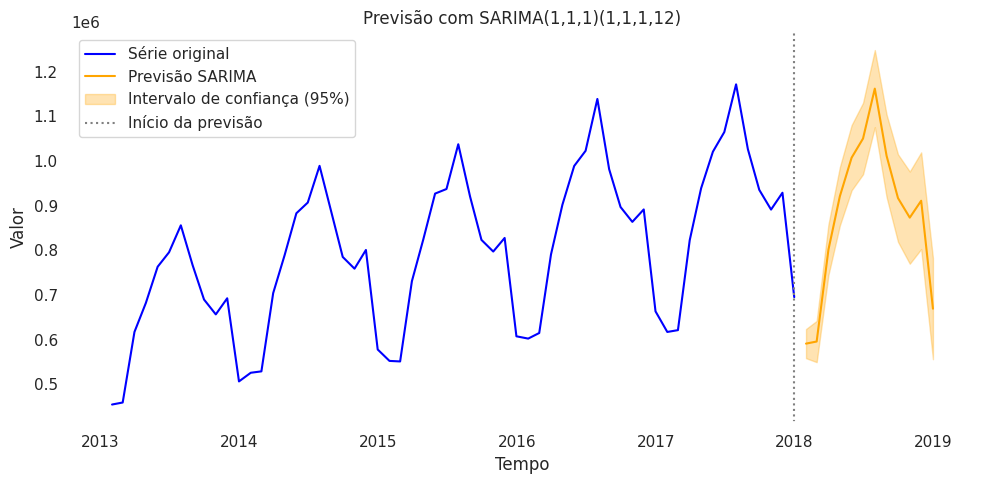

In [11]:
n_forecast = 12
forecast_res = final_fit.get_forecast(steps=n_forecast)

forecast_mean = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int()

forecast_index = pd.date_range(start=df.index[-1] + pd.offsets.MonthEnd(1),
                               periods=n_forecast, freq='ME')
forecast_mean.index = forecast_index
forecast_ci.index = forecast_index

plt.figure(figsize=(10,5))
plt.plot(df['sales'], label='Série original', color='blue')

plt.plot(forecast_mean, label='Previsão SARIMA', color='orange')

plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:,0],
                 forecast_ci.iloc[:,1],
                 color='orange', alpha=0.3, label='Intervalo de confiança (95%)')

plt.axvline(x=df.index[-1], color='gray', linestyle=':', label='Início da previsão')

plt.title('Previsão com SARIMA(1,1,1)(1,1,1,12)')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()